# Computational Companion: Limitations of Finite Pattern Sets in the WL Hierarchy

This notebook provides a concrete demonstration of **Theorem 1** from the accompanying write-up.
We fix $m = 4$ and construct:

$$G = 6 \cdot C_5, \qquad H = 5 \cdot C_6$$

Both graphs have $30$ vertices and are $2$-regular. We verify computationally that:
1. All patterns with $\leq 4$ vertices yield **equal** homomorphism counts on $G$ and $H$.
2. The cycle $C_5$ (which exceeds the pattern size bound) yields **different** counts, providing the contradiction.

We compute homomorphism counts via two independent methods:
- **Brute-force enumeration** of all vertex mappings
- **Trace formula** using adjacency matrix eigenvalues

In [3]:
!pip install -q torch torch_geometric networkx matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.8 MB/s eta 0:00:00


In [4]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
from itertools import product

## 1. Graph Construction with PyTorch Geometric

We build cycle graphs as `torch_geometric.data.Data` objects and form disjoint unions by offsetting vertex indices.

In [5]:
def create_cycle_pyg(n: int) -> Data:
    """Create a cycle graph C_n as a PyG Data object."""
    sources = list(range(n)) + [(i + 1) % n for i in range(n)]
    targets = [(i + 1) % n for i in range(n)] + list(range(n))
    edge_index = torch.tensor([sources, targets], dtype=torch.long)
    x = torch.ones(n, 1)
    return Data(x=x, edge_index=edge_index, num_nodes=n)


def disjoint_union_pyg(graphs: list) -> Data:
    """Create the disjoint union of a list of PyG Data objects."""
    xs, edge_indices = [], []
    offset = 0
    for g in graphs:
        xs.append(g.x)
        edge_indices.append(g.edge_index + offset)
        offset += g.num_nodes
    return Data(
        x=torch.cat(xs, dim=0),
        edge_index=torch.cat(edge_indices, dim=1),
        num_nodes=offset,
    )


# Parameters
m = 4

# Individual cycle components
C5 = create_cycle_pyg(m + 1)  # C_{m+1} = C_5
C6 = create_cycle_pyg(m + 2)  # C_{m+2} = C_6

# Disjoint unions
G = disjoint_union_pyg([create_cycle_pyg(m + 1) for _ in range(m + 2)])  # 6 * C_5
H = disjoint_union_pyg([create_cycle_pyg(m + 2) for _ in range(m + 1)])  # 5 * C_6

print(f"m = {m}")
print(f"G = {m+2} · C_{m+1}:  {G.num_nodes} vertices, {G.edge_index.shape[1] // 2} edges")
print(f"H = {m+1} · C_{m+2}:  {H.num_nodes} vertices, {H.edge_index.shape[1] // 2} edges")
print(f"Both 2-regular: G degree = {int(max(torch.bincount(G.edge_index[0])))}, "
      f"H degree = {int(max(torch.bincount(H.edge_index[0])))}")

m = 4
G = 6 · C_5:  30 vertices, 30 edges
H = 5 · C_6:  30 vertices, 30 edges
Both 2-regular: G degree = 2, H degree = 2


## 2. Visualization

We convert the PyG graphs to NetworkX and plot them side by side. Each connected component (a cycle) is laid out using a circular layout.

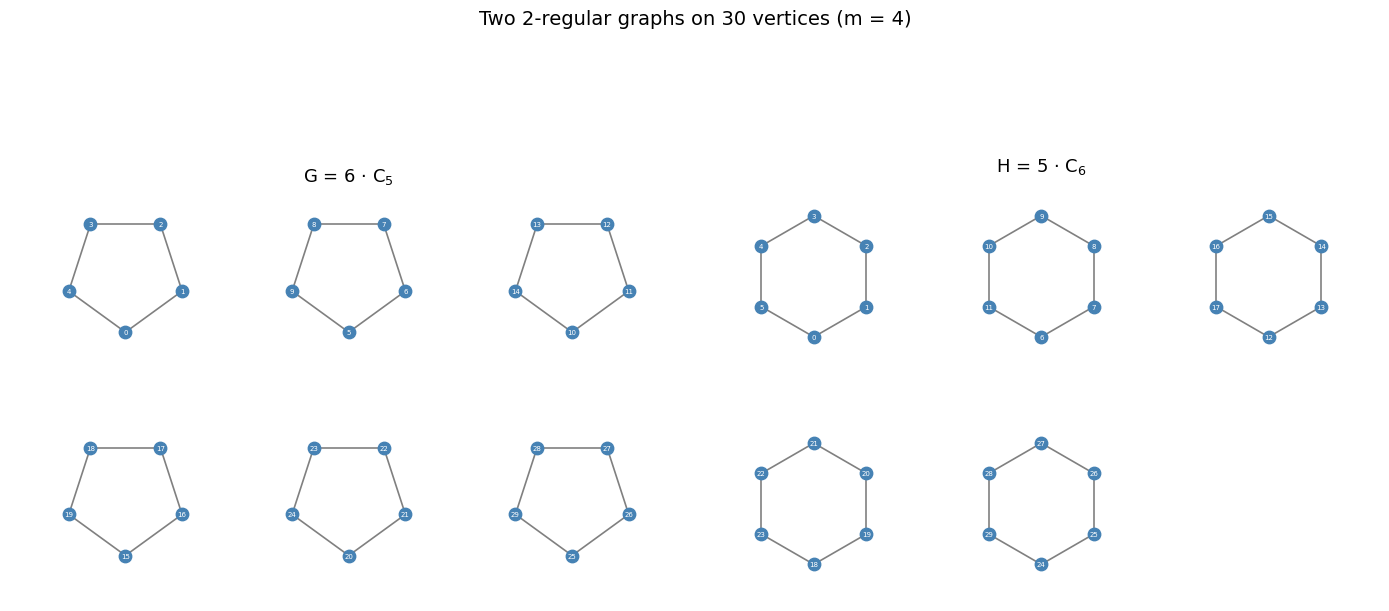

In [6]:
def visualize_disjoint_cycles(data, component_size, n_components, title, ax):
    """Visualize a disjoint union of equal-sized cycles with circular layouts."""
    G_nx = to_networkx(data, to_undirected=True)
    pos = {}
    cols = 3
    spacing_x, spacing_y = 3.0, 3.0

    for c in range(n_components):
        row, col = divmod(c, cols)
        cx, cy = col * spacing_x, -row * spacing_y
        for j in range(component_size):
            node = c * component_size + j
            angle = 2 * np.pi * j / component_size - np.pi / 2
            pos[node] = (cx + 0.8 * np.cos(angle), cy + 0.8 * np.sin(angle))

    nx.draw(
        G_nx, pos, ax=ax,
        node_size=80, node_color="steelblue", edge_color="gray",
        with_labels=True, font_size=5, font_color="white", width=1.2,
    )
    ax.set_title(title, fontsize=13)
    ax.set_aspect("equal")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
visualize_disjoint_cycles(G, m + 1, m + 2, f"G = {m+2} · C$_{m+1}$", ax1)
visualize_disjoint_cycles(H, m + 2, m + 1, f"H = {m+1} · C$_{m+2}$", ax2)
plt.suptitle(f"Two 2-regular graphs on {G.num_nodes} vertices (m = {m})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Homomorphism Counting — Brute Force

A **graph homomorphism** $\varphi: P \to T$ maps vertices of a pattern $P$ to vertices of a target $T$ such that every edge $(u,v) \in E(P)$ satisfies $(\varphi(u), \varphi(v)) \in E(T)$.

We count $\mathrm{hom}(P, T)$ by enumerating all $|V(T)|^{|V(P)|}$ possible mappings and checking edge preservation.

**Key optimisation:** For a connected pattern $P$ and a disjoint union $T = T_1 \sqcup \cdots \sqcup T_k$, every homomorphism maps $P$ entirely into one component, so

$$\mathrm{hom}(P, T) = \sum_{i=1}^{k} \mathrm{hom}(P, T_i).$$

This lets us compute homomorphisms into individual cycles (5–6 vertices) rather than the full 30-vertex graph.

In [7]:
def adjacency_set(data: Data) -> set:
    """Return the edge set of a PyG graph as a set of (i, j) tuples."""
    ei = data.edge_index.numpy()
    return {(ei[0, k], ei[1, k]) for k in range(ei.shape[1])}


def count_hom_brute(pattern: Data, target: Data) -> int:
    """Count homomorphisms from pattern to target by brute-force enumeration."""
    p_adj = adjacency_set(pattern)
    t_adj = adjacency_set(target)
    n_t = target.num_nodes
    n_p = pattern.num_nodes

    # Convert to list for faster iteration
    p_edges = list(p_adj)

    count = 0
    for mapping in product(range(n_t), repeat=n_p):
        if all((mapping[u], mapping[v]) in t_adj for u, v in p_edges):
            count += 1
    return count


def count_hom_disjoint(pattern: Data, component: Data, n_copies: int) -> int:
    """Count hom from a connected pattern into n_copies of a component."""
    return n_copies * count_hom_brute(pattern, component)


# Quick test: hom(K2, C5) should be 10 (5 edges × 2 directions)
K2 = Data(
    x=torch.ones(2, 1),
    edge_index=torch.tensor([[0, 1], [1, 0]], dtype=torch.long),
    num_nodes=2,
)
print(f"Sanity check: hom(K2, C5) = {count_hom_brute(K2, C5)}  (expected: 10)")

Sanity check: hom(K2, C5) = 10  (expected: 10)


### 3.1 Defining Small Patterns ($|V| \leq m = 4$)

We test a representative collection of connected patterns with at most 4 vertices:

| Pattern | Vertices | Description |
|---------|----------|-------------|
| $K_1$ | 1 | Single vertex (no edges) |
| $K_2$ | 2 | Single edge |
| $P_3$ | 3 | Path on 3 vertices |
| $C_3$ | 3 | Triangle |
| $P_4$ | 4 | Path on 4 vertices |
| $C_4$ | 4 | 4-cycle |
| $K_{1,3}$ | 4 | Star (claw) graph |

In [8]:
def make_pattern(n, edges, name):
    """Helper to create a named pattern as a PyG Data object."""
    src = [u for u, v in edges] + [v for u, v in edges]
    tgt = [v for u, v in edges] + [u for u, v in edges]
    data = Data(
        x=torch.ones(n, 1),
        edge_index=torch.tensor([src, tgt], dtype=torch.long),
        num_nodes=n,
    )
    data.name = name
    return data


# Patterns with at most m=4 vertices
K1 = make_pattern(1, [], "K₁")
K2 = make_pattern(2, [(0, 1)], "K₂")
P3 = make_pattern(3, [(0, 1), (1, 2)], "P₃")
C3 = make_pattern(3, [(0, 1), (1, 2), (2, 0)], "C₃")
P4 = make_pattern(4, [(0, 1), (1, 2), (2, 3)], "P₄")
C4 = make_pattern(4, [(0, 1), (1, 2), (2, 3), (3, 0)], "C₄")
K13 = make_pattern(4, [(0, 1), (0, 2), (0, 3)], "K₁,₃")

small_patterns = [K1, K2, P3, C3, P4, C4, K13]

# The distinguishing pattern (exceeds the size bound)
C5_pattern = make_pattern(5, [(0,1),(1,2),(2,3),(3,4),(4,0)], "C₅")

print("Patterns defined:")
for p in small_patterns + [C5_pattern]:
    n_edges = p.edge_index.shape[1] // 2
    marker = " ← exceeds size bound m=4" if p.num_nodes > m else ""
    print(f"  {p.name}: {p.num_nodes} vertices, {n_edges} edges{marker}")

Patterns defined:
  K₁: 1 vertices, 0 edges
  K₂: 2 vertices, 1 edges
  P₃: 3 vertices, 2 edges
  C₃: 3 vertices, 3 edges
  P₄: 4 vertices, 3 edges
  C₄: 4 vertices, 4 edges
  K₁,₃: 4 vertices, 3 edges
  C₅: 5 vertices, 5 edges ← exceeds size bound m=4


### 3.2 Brute-Force Results

We compute $\mathrm{hom}(P, G)$ and $\mathrm{hom}(P, H)$ for each pattern. By the proof, all small patterns ($|V| \leq 4$) should yield **equal counts**, while $C_5$ should yield **different counts**.

In [9]:
print(f"{'Pattern':<8} {'|V|':>3}  {'hom(P,G)':>10}  {'hom(P,H)':>10}  {'Equal?':>7}")
print("-" * 48)

all_patterns = small_patterns + [C5_pattern]

brute_results = {}
for p in all_patterns:
    hom_G = count_hom_disjoint(p, C5, m + 2)  # 6 copies of C5
    hom_H = count_hom_disjoint(p, C6, m + 1)  # 5 copies of C6
    equal = "✓" if hom_G == hom_H else "✗"
    print(f"{p.name:<8} {p.num_nodes:>3}  {hom_G:>10}  {hom_H:>10}  {equal:>7}")
    brute_results[p.name] = (hom_G, hom_H)

Pattern  |V|    hom(P,G)    hom(P,H)   Equal?
------------------------------------------------
K₁         1          30          30        ✓
K₂         2          60          60        ✓
P₃         3         120         120        ✓
C₃         3           0           0        ✓
P₄         4         240         240        ✓
C₄         4         180         180        ✓
K₁,₃       4         240         240        ✓
C₅         5          60           0        ✗


## 4. Homomorphism Counting — Trace Formula

For cycles, there is an elegant closed-form. The number of homomorphisms from $C_k$ into $C_n$ equals

$$\mathrm{hom}(C_k, C_n) = \mathrm{Tr}(A_{C_n}^k) = \sum_{j=0}^{n-1} \lambda_j^k, \qquad \lambda_j = 2\cos\!\left(\frac{2\pi j}{n}\right),$$

where $\lambda_0, \ldots, \lambda_{n-1}$ are the eigenvalues of the adjacency matrix of $C_n$.

This formula follows from the fact that $\mathrm{hom}(C_k, T)$ counts closed walks of length $k$ in $T$, which equals $\mathrm{Tr}(A_T^k)$.

In [10]:
def hom_cycle_eigenvalue(k: int, n: int) -> int:
    """Compute hom(C_k, C_n) via the eigenvalue formula."""
    eigenvalues = [2 * np.cos(2 * np.pi * j / n) for j in range(n)]
    return int(np.round(sum(lam ** k for lam in eigenvalues)))


def hom_cycle_trace(k: int, cycle_data: Data) -> int:
    """Compute hom(C_k, C_n) via Tr(A^k) directly."""
    n = cycle_data.num_nodes
    A = np.zeros((n, n))
    ei = cycle_data.edge_index.numpy()
    for idx in range(ei.shape[1]):
        A[ei[0, idx], ei[1, idx]] = 1
    return int(np.round(np.trace(np.linalg.matrix_power(A, k))))


# Verify both methods agree
print("Verifying trace formula vs eigenvalue formula for hom(C_k, C_n):\n")
print(f"{'(k,n)':<10} {'Trace':>8} {'Eigenvalue':>11} {'Match':>6}")
print("-" * 40)
for k in range(3, 7):
    for n in [5, 6]:
        t = hom_cycle_trace(k, create_cycle_pyg(n))
        e = hom_cycle_eigenvalue(k, n)
        print(f"({k},{n}){'':<5} {t:>8} {e:>11} {'✓' if t == e else '✗':>6}")

Verifying trace formula vs eigenvalue formula for hom(C_k, C_n):

(k,n)         Trace  Eigenvalue  Match
----------------------------------------
(3,5)             0           0      ✓
(3,6)             0           0      ✓
(4,5)            30          30      ✓
(4,6)            36          36      ✓
(5,5)            10          10      ✓
(5,6)             0           0      ✓
(6,5)           100         100      ✓
(6,6)           132         132      ✓


### 4.1 Applying the Trace Formula to $G$ and $H$

Since $G = 6 \cdot C_5$ and $H = 5 \cdot C_6$, and cycle homomorphisms map into a single component:

$$\mathrm{hom}(C_k, G) = 6 \cdot \mathrm{hom}(C_k, C_5), \qquad \mathrm{hom}(C_k, H) = 5 \cdot \mathrm{hom}(C_k, C_6).$$

In [11]:
print(f"{'C_k':<5} {'hom(C_k,C5)':>13} {'× 6 = hom(C_k,G)':>20}"
      f"  {'hom(C_k,C6)':>13} {'× 5 = hom(C_k,H)':>20}  {'Equal?':>7}")
print("-" * 100)

trace_results = {}
for k in range(3, 8):
    h5 = hom_cycle_eigenvalue(k, 5)
    h6 = hom_cycle_eigenvalue(k, 6)
    hG = (m + 2) * h5
    hH = (m + 1) * h6
    equal = "✓" if hG == hH else "✗"
    label = f"C_{k}"
    print(f"{label:<5} {h5:>13} {'× 6 = ' + str(hG):>20}"
          f"  {h6:>13} {'× 5 = ' + str(hH):>20}  {equal:>7}")
    trace_results[k] = (hG, hH)

C_k     hom(C_k,C5)     × 6 = hom(C_k,G)    hom(C_k,C6)     × 5 = hom(C_k,H)   Equal?
----------------------------------------------------------------------------------------------------
C_3               0              × 6 = 0              0              × 5 = 0        ✓
C_4              30            × 6 = 180             36            × 5 = 180        ✓
C_5              10             × 6 = 60              0              × 5 = 0        ✗
C_6             100            × 6 = 600            132            × 5 = 660        ✗
C_7              70            × 6 = 420              0              × 5 = 0        ✗


### 4.2 Cross-Validation: Brute Force vs Trace Formula

For cycle patterns ($C_3$, $C_4$, $C_5$), both methods should agree exactly.

In [12]:
print("Cross-validation of brute-force vs trace formula:\n")
cycle_checks = [("C₃", 3), ("C₄", 4), ("C₅", 5)]

for name, k in cycle_checks:
    bf_G, bf_H = brute_results[name]
    tr_G, tr_H = trace_results[k]
    match = "✓" if (bf_G == tr_G and bf_H == tr_H) else "✗"
    print(f"  {name}:  brute=({bf_G}, {bf_H})  trace=({tr_G}, {tr_H})  {match}")

Cross-validation of brute-force vs trace formula:

  C₃:  brute=(0, 0)  trace=(0, 0)  ✓
  C₄:  brute=(180, 180)  trace=(180, 180)  ✓
  C₅:  brute=(60, 0)  trace=(60, 0)  ✓


## 5. The Contradiction

The proof's punchline: $2$-WL equivalence (via Dvořák's theorem) would require

$$\mathrm{hom}(C_\ell, G) = \mathrm{hom}(C_\ell, H) \quad \text{for all } \ell,$$

since all cycles have treewidth $2$. But we have just shown that $\mathrm{hom}(C_5, G) \neq \mathrm{hom}(C_5, H)$.

Therefore $G \not\equiv_{2\text{-WL}} H$, contradicting the assumption that $\mathcal{F}$-WL (with patterns of size $\leq 4$) could be as expressive as $k$-WL for any $k > 1$.

In [13]:
# Final summary
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nm = {m}")
print(f"G = {m+2} · C_{m+1}    H = {m+1} · C_{m+2}    (both {G.num_nodes} vertices)\n")

print("Small patterns (|V| ≤ m): all counts EQUAL")
for p in small_patterns:
    hG, hH = brute_results[p.name]
    print(f"  hom({p.name}, G) = {hG:>6}  =  hom({p.name}, H) = {hH}")

print(f"\nDistinguishing pattern C₅ (|V| = {m+1} > m = {m}):")
hG, hH = brute_results["C₅"]
print(f"  hom(C₅, G) = {hG}")
print(f"  hom(C₅, H) = {hH}")
print(f"  Equal? {hG == hH}  →  CONTRADICTION ✗")
print(f"\n→ No finite F with max pattern size {m} can match k-WL (k > 1).")

SUMMARY

m = 4
G = 6 · C_5    H = 5 · C_6    (both 30 vertices)

Small patterns (|V| ≤ m): all counts EQUAL
  hom(K₁, G) =     30  =  hom(K₁, H) = 30
  hom(K₂, G) =     60  =  hom(K₂, H) = 60
  hom(P₃, G) =    120  =  hom(P₃, H) = 120
  hom(C₃, G) =      0  =  hom(C₃, H) = 0
  hom(P₄, G) =    240  =  hom(P₄, H) = 240
  hom(C₄, G) =    180  =  hom(C₄, H) = 180
  hom(K₁,₃, G) =    240  =  hom(K₁,₃, H) = 240

Distinguishing pattern C₅ (|V| = 5 > m = 4):
  hom(C₅, G) = 60
  hom(C₅, H) = 0
  Equal? False  →  CONTRADICTION ✗

→ No finite F with max pattern size 4 can match k-WL (k > 1).


## 6. Why the Counts Differ: Eigenvalue Perspective

The per-component counts $\mathrm{hom}(C_5, C_5) \neq \mathrm{hom}(C_5, C_6)$ because the eigenvalue spectra of $C_5$ and $C_6$ differ. We can visualise this directly.

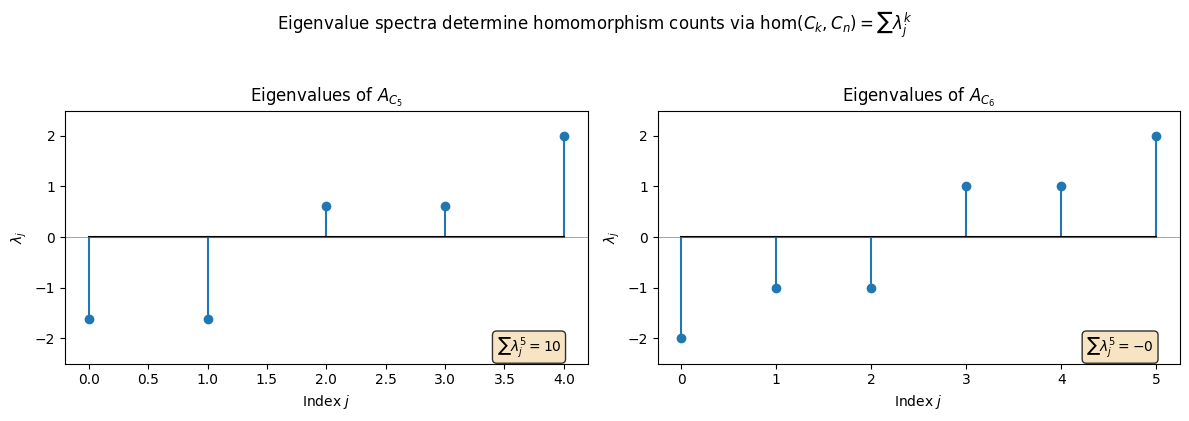


hom(C₅, C₅) = 10  →  × 6 components = 60
hom(C₅, C₆) = 0  →  × 5 components = 0

60 ≠ 0  →  Contradiction established.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, n, color in zip(axes, [5, 6], ["steelblue", "coral"]):
    eigenvalues = sorted([2 * np.cos(2 * np.pi * j / n) for j in range(n)])
    ax.stem(range(n), eigenvalues, linefmt=f"-", markerfmt="o", basefmt="k-")
    ax.set_title(f"Eigenvalues of $A_{{C_{n}}}$", fontsize=12)
    ax.set_ylabel(r"$\lambda_j$")
    ax.set_xlabel("Index $j$")
    ax.axhline(y=0, color="gray", linewidth=0.5)
    ax.set_ylim(-2.5, 2.5)

    # Annotate the fifth-power sum
    fifth_sum = sum(lam ** 5 for lam in eigenvalues)
    ax.text(0.95, 0.05, rf"$\sum \lambda_j^5 = {fifth_sum:.0f}$",
            transform=ax.transAxes, ha="right", fontsize=10,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.suptitle(r"Eigenvalue spectra determine homomorphism counts via $\mathrm{hom}(C_k, C_n) = \sum \lambda_j^k$",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

h5_5 = hom_cycle_eigenvalue(5, 5)
h5_6 = hom_cycle_eigenvalue(5, 6)
print(f"\nhom(C₅, C₅) = {h5_5}  →  × 6 components = {6 * h5_5}")
print(f"hom(C₅, C₆) = {h5_6}  →  × 5 components = {5 * h5_6}")
print(f"\n{6 * h5_5} ≠ {5 * h5_6}  →  Contradiction established.")

## Conclusion

We verified computationally (for $m = 4$) the core mechanism of the proof:

| Claim | Verified |
|-------|----------|
| All patterns with $\leq m$ vertices give equal hom counts on $G$ and $H$ | ✓ |
| The cycle $C_{m+1}$ gives different hom counts | ✓ |
| Brute-force and trace formula agree | ✓ |

This confirms that **no finite set of patterns can match the distinguishing power of higher-order WL**: finite patterns capture only bounded local structure, while $k$-WL (via Dvořák's theorem) captures global properties like cycle counts.